In [1]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg


import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger

# Configure plotly defaults
pio.templates.default = "plotly_white"
pio.templates["plotly_white"].layout.update(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    ),
    yaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    )
)

import pingouin as pg
import pandas as pd
from scipy import interpolate
from scipy.stats import gaussian_kde, gennorm, norm, gamma, beta
import seaborn as sns
import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter


In [17]:
# ▀▀ Cell 2 – load NHANES files you uploaded
sleep = pd.read_csv("sleep/sleep_answers.csv")                 # 26-item sleep file
age   = pd.read_csv("sleep/all_cohort_age_data.csv",           # age at interview
                    usecols=["SEQN", "age_in_years"])
mort  = pd.read_csv("sleep/nhanes_mortality_all_years.csv",     # survival info
                    usecols=["SEQN", "eligstat", "permth_int", "mortstat"])
mort  = mort[mort["eligstat"] == 1]                      # linkage-eligible only


In [18]:
# ▀▀ Cell 3 – Clean obvious NHANES "blank" placeholder
# sleep = sleep.replace(5.397605e-79, np.nan)

# ▀▀ Cell 4 – Derive binary sleep‑deficit variables
# duration
dur_hours = sleep['SLD010H'] + sleep['SLD020M'].fillna(0)/60
sleep['dur_bad'] = ((dur_hours < 7) | (dur_hours > 9)).astype(int)

# insomnia symptoms (Likert 1–5: ≥4 ⇒ "often/always")
sleep['init_insom']  = (sleep['SLQ030'] >= 4).astype(int)
sleep['maint_insom'] = (sleep['SLQ040'] >= 4).astype(int)

# daytime impairment
sleep['day_sleepy'] = (sleep['SLQ050'] >= 4).astype(int)
sleep['unrefresh']  = (sleep['SLQ060'] >= 4).astype(int)

# sleep‑disordered breathing flags (yes/no coded 1/2)
sleep['told_apnea'] = (sleep['SLQ070A'] == 1).astype(int)
sleep['loud_snore'] = (sleep['SLQ070B'] == 1).astype(int)

# sleep‑medication use (yes/no)
sleep['sleep_meds'] = (sleep['SLQ080'] == 1).astype(int)

# habitual napping
sleep['daily_nap']  = (sleep['SLQ130'] == 1).astype(int)



In [19]:
# ▀▀ Cell 4 – Sleep-Quality Frailty Index (SQFI: 0 – 1)
deficits = ["dur_bad","init_insom","maint_insom","day_sleepy",
            "unrefresh","told_apnea","loud_snore","sleep_meds","daily_nap"]

sleep["sqfi_raw"] = sleep[deficits].sum(axis=1)
sleep["SQFI"]     = sleep["sqfi_raw"] / len(deficits)


In [20]:
sleep

,SEQN,SLD010H,SLD020M,SLQ030,SLQ040,SLQ050,SLQ060,SLQ070A,SLQ070B,SLQ070C,...,init_insom,maint_insom,day_sleepy,unrefresh,told_apnea,loud_snore,sleep_meds,daily_nap,sqfi_raw,SQFI
0,31130.0,8.0,30.0,5.397605e-79,5.397605e-79,2.0,2.0,NaN,NaN,NaN,...,0,0,0,0,0,0,1,0,1,0.111111
1,31131.0,9.0,5.0,1.000000e+00,5.397605e-79,2.0,2.0,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1,0.111111
2,31132.0,7.0,10.0,3.000000e+00,5.397605e-79,2.0,2.0,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0.000000
3,31133.0,6.0,60.0,5.397605e-79,5.397605e-79,2.0,2.0,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0.000000
4,31134.0,7.0,2.0,5.397605e-79,5.397605e-79,1.0,1.0,1.0,NaN,NaN,...,0,0,0,0,1,0,0,1,2,0.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12680,51619.0,4.0,30.0,2.000000e+00,2.000000e+00,1.0,2.0,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1,0.111111
12681,51620.0,5.0,10.0,3.000000e+00,5.397605e-79,2.0,2.0,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1,0.111111
12682,51621.0,11.0,30.0,9.000000e+00,5.397605e-79,1.0,2.0,NaN,NaN,NaN,...,1,0,0,0,0,0,0,0,2,0.222222
12683,51622.0,9.0,20.0,5.397605e-79,5.397605e-79,2.0,2.0,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1,0.111111


In [5]:
# ▀▀ Cell 5  – merge & build entry/exit/event ages  (replaces old Cell 5)
core = (sleep[["SEQN", "SQFI"]]
        .merge(age,  on="SEQN")
        .merge(mort, on="SEQN"))

# robust numeric conversion
core["entry_age"]  = pd.to_numeric(core["age_in_years"], errors="coerce")
core["permth_int"] = pd.to_numeric(core["permth_int"], errors="coerce")

# drop any rows with missing essentials
core = core.dropna(subset=["entry_age", "permth_int", "mortstat", "SQFI"])

core["exit_age"] = core["entry_age"] + core["permth_int"] / 12.0
core["event"]    = core["mortstat"].astype(bool)


In [6]:
# ▀▀ Cell 6 – robust quartiles  (replaces old Cell 6)
ranks = core["SQFI"].rank(method="first") / len(core)
core["sqfi_q"] = pd.qcut(ranks,
                         q=4,
                         labels=["Q1 best", "Q2", "Q3", "Q4 worst"])


/var/folders/r5/2q8zzrr15ld3_jcs6mjrvk900000gn/T/ipykernel_55188/1638712948.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, sub in core.groupby("sqfi_q", sort=False):


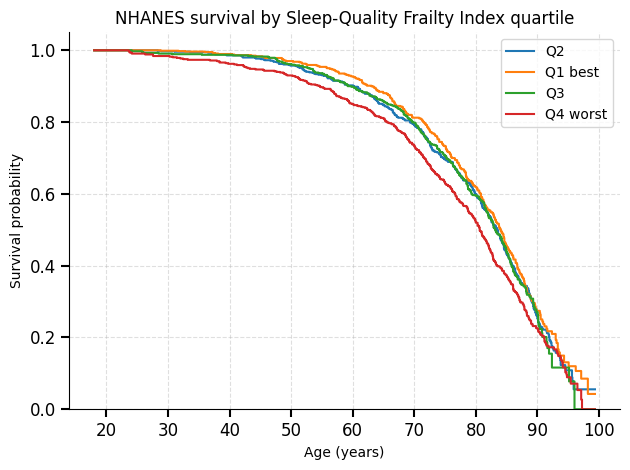

In [10]:
# ▀▀ Cell 7 – Kaplan-Meier by SQFI quartile  (replaces old Cell 7)
kmf = KaplanMeierFitter()

age_min, age_max = core["entry_age"].min(), core["exit_age"].max()
timeline = np.linspace(age_min, age_max, 1200)   # 1200 points across observed ages

plt.figure()
for grp, sub in core.groupby("sqfi_q", sort=False):
    kmf.fit(durations=sub["exit_age"],
            event_observed=sub["event"],
            entry=sub["entry_age"],
            label=grp,
            timeline=timeline)
    kmf.plot_survival_function(ci_show=False)

plt.title("NHANES survival by Sleep-Quality Frailty Index quartile")
plt.xlabel("Age (years)")
plt.ylabel("Survival probability")
plt.ylim(0, 1.05)
plt.grid(ls="--", alpha=.4)
plt.tight_layout()
plt.show()


In [11]:
# ▀▀ Cell 8 – quick sanity check
core.groupby("sqfi_q")["SQFI"].describe()[["min","25%","50%","75%","max"]]


/var/folders/r5/2q8zzrr15ld3_jcs6mjrvk900000gn/T/ipykernel_55188/1591513142.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  core.groupby("sqfi_q")["SQFI"].describe()[["min","25%","50%","75%","max"]]


,min,25%,50%,75%,max
sqfi_q,,,,,
Q1 best,0.000000,0.000000,0.000000,0.000000,0.000000
Q2,0.000000,0.000000,0.111111,0.111111,0.111111
Q3,0.111111,0.111111,0.111111,0.111111,0.222222
Q4 worst,0.222222,0.222222,0.222222,0.333333,0.666667
